In [1]:
library(tidyterra)
library(terra)
library(geodata)
library(rnaturalearth)
library(ggplot2)
library(dplyr)
library(sf)
library(rlang)
library(knitr)
library(patchwork)
library(leaflet)
library(htmlwidgets)
library(htmltools)
library(raster)
library(IRdisplay)


Attaching package: ‘tidyterra’




The following object is masked from ‘package:stats’:

    filter




terra 1.9.27




Attaching package: ‘dplyr’




The following objects are masked from ‘package:terra’:

    intersect, union




...

The following object is masked from ‘package:terra’:

    area




Loading required package: sp




Attaching package: ‘raster’




The following object is masked from ‘package:dplyr’:

    select




The following object is masked from ‘package:tidyterra’:

    select




## United Rugby Championship (URC)

The **United Rugby Championship** spans **Ireland**, the **United Kingdom** (including **Northern Ireland**), **Wales**, **Scotland**, **Italy**, and **South Africa**. Unlike the English Premiership notebook, we cannot use a single **GBR** elevation tile: we pull **SRTM 30 arc-second** rasters from **`geodata::elevation_30s()`** for **`IRL`**, **`GBR`**, **`ITA`**, and **`ZAF`**, then sample the correct national raster for each stadium so we never merge full-country grids in memory.

**Stadium coordinates** below are approximate centre points for each club’s usual home ground (sources: club / venue pages and maps). If you need survey-grade coordinates or a different season’s venues, replace the `urc_clubs` table and rebuild.

In [2]:
urc_clubs <- data.frame(
  club = c(
    "Leinster", "Munster", "Ulster", "Connacht",
    "Glasgow Warriors", "Edinburgh",
    "Cardiff Rugby", "Ospreys", "Scarlets", "Dragons",
    "Benetton", "Zebre Parma",
    "Bulls", "Stormers", "Sharks", "Lions"
  ),
  stadium = c(
    "RDS Arena", "Thomond Park", "Kingspan Stadium", "The Sportsground",
    "Scotstoun Stadium", "Scottish Gas Murrayfield",
    "Cardiff Arms Park", "Swansea.com Stadium", "Parc y Scarlets", "Rodney Parade",
    "Stadio Monigo", "Stadio Lanfranchi",
    "Loftus Versfeld", "DHL Stadium", "Hollywoodbets Kings Park", "Emirates Airline Park"
  ),
  lon = c(
    -6.226, -8.618, -5.943, -9.077,
    -4.335, -3.240,
    -3.170, -3.941, -4.128, -2.991,
    12.229, 10.333,
    28.229, 18.411, 31.030, 28.061
  ),
  lat = c(
    53.325, 52.674, 54.576, 53.279,
    55.881, 55.942,
    51.479, 51.693, 51.679, 51.588,
    45.683, 44.800,
    -25.748, -33.903, -29.825, -26.198
  ),
  country = c(
    "Ireland", "Ireland", "United Kingdom", "Ireland",
    "United Kingdom", "United Kingdom",
    "United Kingdom", "United Kingdom", "United Kingdom", "United Kingdom",
    "Italy", "Italy",
    "South Africa", "South Africa", "South Africa", "South Africa"
  ),
  elev_source = c(
    "IRL", "IRL", "GBR", "IRL",
    "GBR", "GBR",
    "GBR", "GBR", "GBR", "GBR",
    "ITA", "ITA",
    "ZAF", "ZAF", "ZAF", "ZAF"
  ),
  stringsAsFactors = FALSE
)

urc_sv <- terra::vect(urc_clubs, geom = c("lon", "lat"), crs = "EPSG:4326")

## Download elevation tiles (once per country)

In [3]:
td <- tempdir()
elev_tiles <- list(
  IRL = geodata::elevation_30s(country = "IRL", path = td),
  GBR = geodata::elevation_30s(country = "GBR", path = td),
  ITA = geodata::elevation_30s(country = "ITA", path = td),
  ZAF = geodata::elevation_30s(country = "ZAF", path = td)
)

for (nm in names(elev_tiles)) {
  names(elev_tiles[[nm]]) <- paste0("elev_", nm)
}

Cached as: /var/folders/6j/s6_5p4dj51nbsz36mmbs50680000gn/T//Rtmp7uwE8s/elevation/IRL_elv_msk.zip



Cached as: /var/folders/6j/s6_5p4dj51nbsz36mmbs50680000gn/T//Rtmp7uwE8s/elevation/GBR_elv_msk.zip



Cached as: /var/folders/6j/s6_5p4dj51nbsz36mmbs50680000gn/T//Rtmp7uwE8s/elevation/ITA_elv_msk.zip



Cached as: /var/folders/6j/s6_5p4dj51nbsz36mmbs50680000gn/T//Rtmp7uwE8s/elevation/ZAF_elv_msk.zip



## Extract elevation per ground

In [4]:
extract_point_elev <- function(lon, lat, src) {
  r <- elev_tiles[[src]]
  pts <- terra::vect(
    data.frame(lon = lon, lat = lat),
    geom = c("lon", "lat"),
    crs = "EPSG:4326"
  )
  if (!terra::same.crs(r, pts)) {
    pts <- terra::project(pts, r)
  }
  ex <- terra::extract(r, pts)
  as.numeric(ex[[names(r)[1]]])
}

urc_elev <- urc_clubs |>
  mutate(
    ground_elevation_m = mapply(
      extract_point_elev,
      lon,
      lat,
      elev_source,
      USE.NAMES = FALSE
    )
  )

urc_elev |>
  arrange(desc(ground_elevation_m)) |>
  knitr::kable(
    digits = 1,
    caption = "URC grounds ranked by extracted elevation (m a.s.l.; national SRTM tile)"
  )



Table: URC grounds ranked by extracted elevation (m a.s.l.; national SRTM tile)

|club             |stadium                  |  lon|   lat|country        |elev_source | ground_elevation_m|
|:----------------|:------------------------|----:|-----:|:--------------|:-----------|------------------:|
|Lions            |Emirates Airline Park    | 28.1| -26.2|South Africa   |ZAF         |               1727|
|Bulls            |Loftus Versfeld          | 28.2| -25.7|South Africa   |ZAF         |               1385|
|Ospreys          |Swansea.com Stadium      | -3.9|  51.7|United Kingdom |GBR         |                107|
|Zebre Parma      |Stadio Lanfranchi        | 10.3|  44.8|Italy          |ITA         |                 66|
|Edinburgh        |Scottish Gas Murrayfield | -3.2|  55.9|United Kingdom |GBR         |                 47|
|Ulster           |Kingspan Stadium         | -5.9|  54.6|United Kingdom |GBR         |                 26|
|Connacht         |The Sportsground         | -9.1|  

The bar chart orders clubs from **lowest** to **highest** extracted elevation using the same values as the table.

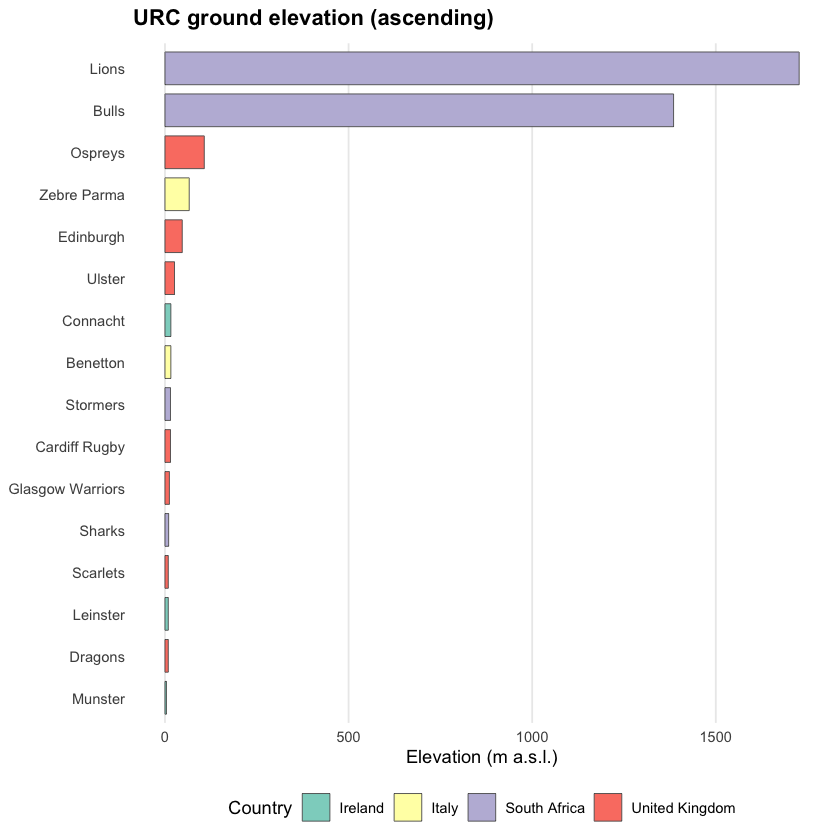

In [5]:
urc_bar <- urc_elev |>
  mutate(club = stats::reorder(club, ground_elevation_m))

ggplot(urc_bar, aes(x = club, y = ground_elevation_m, fill = country)) +
  geom_col(width = 0.78, colour = "grey35", linewidth = 0.25) +
  coord_flip() +
  scale_fill_brewer(palette = "Set3", name = "Country") +
  labs(
    title = "URC ground elevation (ascending)",
    x = NULL,
    y = "Elevation (m a.s.l.)"
  ) +
  theme_minimal(base_size = 11) +
  theme(
    plot.title = element_text(face = "bold", hjust = 0, margin = margin(b = 8)),
    panel.grid.major.y = element_blank(),
    panel.grid.minor = element_blank(),
    legend.position = "bottom"
  )

**Bulls** and **Lions** both play on the South African **Highveld** (Johannesburg and Pretoria), where the 30 arc-second DEM routinely returns **roughly 1.2–1.7 km** above sea level. Those two values sit far above every European and coastal URC ground, so the first chart’s vertical scale is dominated by them: differences of a few tens of metres between, say, Irish and Welsh venues are visually squashed.

Dropping **Bulls** and **Lions** for a second view is therefore a deliberate **outlier removal** for readability—not a claim they are “wrong”, but a way to **stretch the axis** so relative ordering among the remaining fourteen clubs is visible.

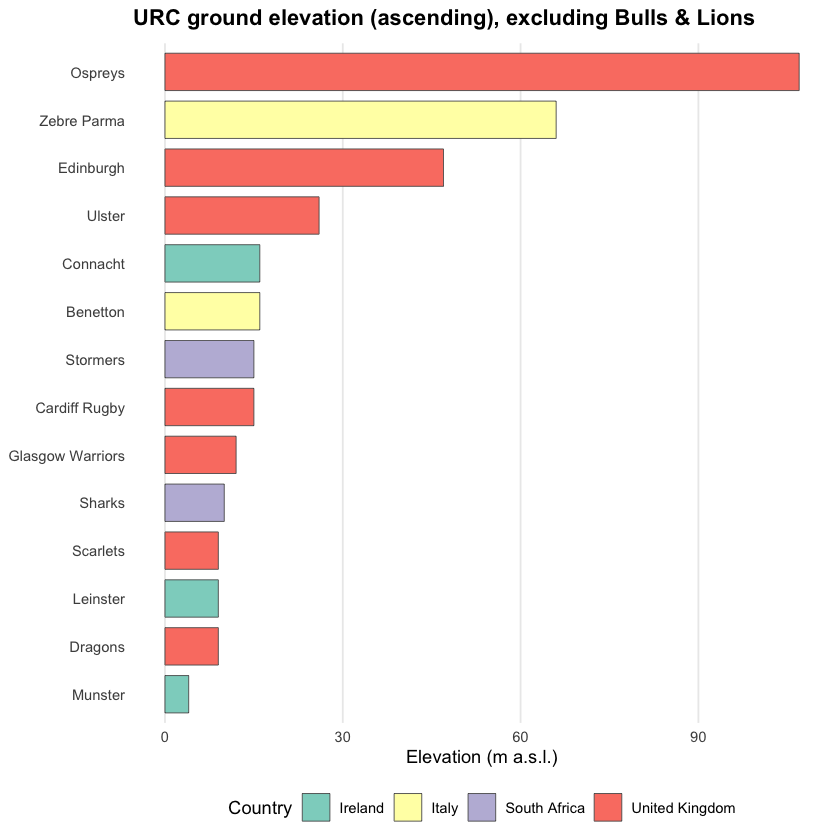

In [6]:
urc_bar_trim <- urc_elev |>
  dplyr::filter(!club %in% c("Bulls", "Lions")) |>
  mutate(club = stats::reorder(club, ground_elevation_m))

ggplot(urc_bar_trim, aes(x = club, y = ground_elevation_m, fill = country)) +
  geom_col(width = 0.78, colour = "grey35", linewidth = 0.25) +
  coord_flip() +
  scale_fill_brewer(palette = "Set3", name = "Country") +
  labs(
    title = "URC ground elevation (ascending), excluding Bulls & Lions",
    x = NULL,
    y = "Elevation (m a.s.l.)"
  ) +
  theme_minimal(base_size = 11) +
  theme(
    plot.title = element_text(face = "bold", hjust = 0, margin = margin(b = 8)),
    panel.grid.major.y = element_blank(),
    panel.grid.minor = element_blank(),
    legend.position = "bottom"
  )

## Regional maps (Europe and South Africa)

European URC clubs sit on **IRL / GBR / ITA** tiles; South African sides use **ZAF**. We **crop** each national raster to a modest bounding box around the relevant grounds, **merge** the European crops for one hypsometric panel, and show **South Africa** separately so the aspect scales remain readable.

In [7]:
world_sf <- rnaturalearth::ne_countries(scale = "medium", returnclass = "sf")
urc_outline_sf <- world_sf[world_sf$iso_a3 %in% c("GBR", "IRL", "ITA", "ZAF"), ]
urc_outline <- terra::vect(urc_outline_sf)

eur_df <- urc_clubs |> dplyr::filter(elev_source != "ZAF")
sa_df <- urc_clubs |> dplyr::filter(elev_source == "ZAF")

eur_ext <- terra::extend(terra::ext(terra::vect(eur_df, geom = c("lon", "lat"), crs = "EPSG:4326")), 2)
sa_ext <- terra::extend(terra::ext(terra::vect(sa_df, geom = c("lon", "lat"), crs = "EPSG:4326")), 2)

r_eur <- terra::merge(
  terra::crop(elev_tiles$IRL, eur_ext),
  terra::merge(
    terra::crop(elev_tiles$GBR, eur_ext),
    terra::crop(elev_tiles$ITA, eur_ext)
  )
)
names(r_eur) <- "elevation"

r_sa <- terra::crop(elev_tiles$ZAF, sa_ext)
names(r_sa) <- "elevation"

eur_pts <- terra::vect(eur_df, geom = c("lon", "lat"), crs = "EPSG:4326")
sa_pts <- terra::vect(sa_df, geom = c("lon", "lat"), crs = "EPSG:4326")

outline_eur <- terra::crop(urc_outline, eur_ext)
outline_sa <- terra::crop(urc_outline, sa_ext)

if (!terra::same.crs(r_eur, outline_eur)) {
  outline_eur <- terra::project(outline_eur, r_eur)
}
if (!terra::same.crs(r_sa, outline_sa)) {
  outline_sa <- terra::project(outline_sa, r_sa)
}

<SpatRaster> resampled to 501410 cells.


Warning message:
“The `label.size` argument of `geom_label()` is deprecated as of ggplot2 3.5.0.
ℹ Please use the `linewidth` argument instead.
ℹ The deprecated feature was likely used in the tidyterra package.
  Please report the issue at <https://github.com/dieghernan/tidyterra/issues>.”


<SpatRaster> resampled to 500286 cells.


Warning message in st_point_on_surface.sfc(sf::st_zm(x)):
“st_point_on_surface may not give correct results for longitude/latitude data”


Warning message in st_point_on_surface.sfc(sf::st_zm(x)):
“st_point_on_surface may not give correct results for longitude/latitude data”


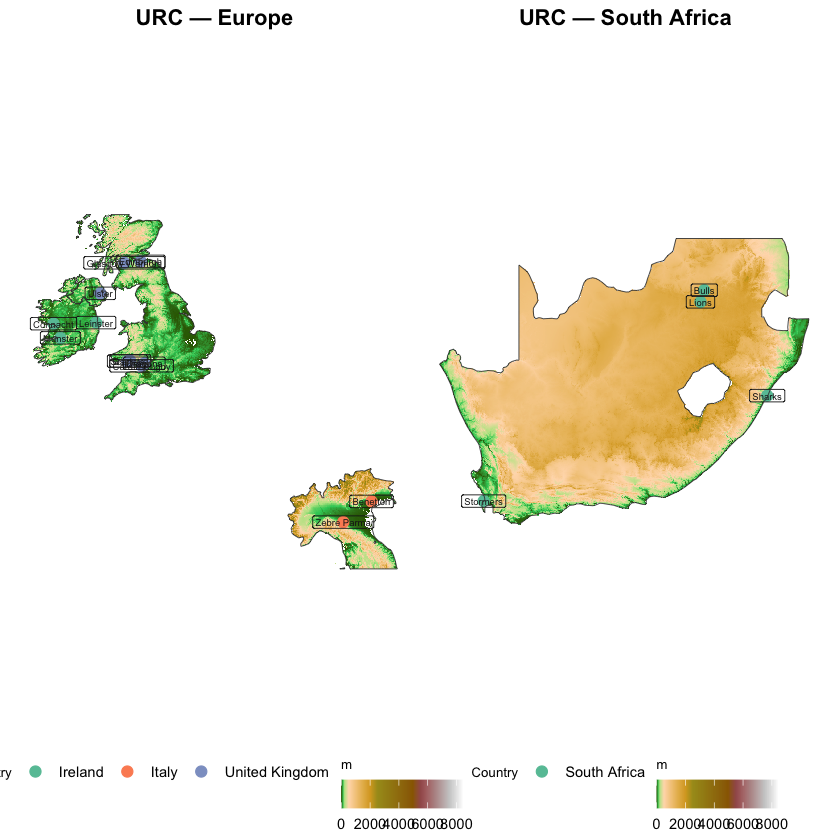

In [8]:
p_eur <- ggplot() +
  tidyterra::geom_spatraster(data = r_eur, aes(fill = elevation)) +
  tidyterra::scale_fill_hypso_tint_c(
    name = "m",
    guide = guide_colorbar(barwidth = unit(2.6, "cm"), title.position = "top")
  ) +
  tidyterra::geom_spatvector(data = eur_pts, aes(colour = country), size = 2.8, show.legend = TRUE) +
  tidyterra::geom_spatvector_label(
    data = eur_pts,
    aes(label = club),
    size = 2,
    colour = "grey10",
    label.size = 0.12,
    show.legend = FALSE
  ) +
  tidyterra::geom_spatvector(data = outline_eur, fill = NA, colour = "grey25", linewidth = 0.25) +
  scale_colour_brewer(palette = "Set2", name = "Country") +
  labs(title = "URC — Europe") +
  theme_void() +
  theme(
    plot.title = element_text(face = "bold", hjust = 0.5, margin = margin(b = 4)),
    legend.title = element_text(size = 8),
    legend.position = "bottom"
  )

p_sa <- ggplot() +
  tidyterra::geom_spatraster(data = r_sa, aes(fill = elevation)) +
  tidyterra::scale_fill_hypso_tint_c(
    name = "m",
    guide = guide_colorbar(barwidth = unit(2.6, "cm"), title.position = "top")
  ) +
  tidyterra::geom_spatvector(data = sa_pts, aes(colour = country), size = 2.8, show.legend = TRUE) +
  tidyterra::geom_spatvector_label(
    data = sa_pts,
    aes(label = club),
    size = 2,
    colour = "grey10",
    label.size = 0.12,
    show.legend = FALSE
  ) +
  tidyterra::geom_spatvector(data = outline_sa, fill = NA, colour = "grey25", linewidth = 0.25) +
  scale_colour_brewer(palette = "Set2", name = "Country") +
  labs(title = "URC — South Africa") +
  theme_void() +
  theme(
    plot.title = element_text(face = "bold", hjust = 0.5, margin = margin(b = 4)),
    legend.title = element_text(size = 8),
    legend.position = "bottom"
  )

p_eur + p_sa + patchwork::plot_layout(ncol = 2, widths = c(1, 1))

### Interactive maps

The maps below use **Leaflet** (via **`htmlwidgets`**). You can **pan**, **zoom**, and click stadium markers for **club**, **venue**, and **extracted elevation**. Marker colours follow the same **elevation colour scale** as the terrain layer. An internet connection is required for the light **basemap** tiles.

In [9]:
flip_raster_east_west <- function(r) {
  mat <- terra::values(r, mat = TRUE)
  mat <- mat[, rev(seq_len(ncol(mat))), drop = FALSE]
  terra::values(r) <- mat
  r
}

leaflet_elev_map <- function(r, clubs_df) {
  r_small <- terra::aggregate(r, fact = 4, fun = mean)
  if (!grepl("4326", terra::crs(r_small, describe = TRUE)$code)) {
    r_small <- terra::project(r_small, "EPSG:4326")
  }
  r_small <- flip_raster_east_west(r_small)
  vals <- terra::values(r_small)
  vals <- vals[!is.na(vals)]
  elev_domain <- range(
    c(vals, clubs_df$ground_elevation_m),
    na.rm = TRUE
  )

  pal <- leaflet::colorNumeric(
    grDevices::terrain.colors(60),
    domain = elev_domain,
    na.color = "#808080"
  )

  lng1 <- terra::xmin(r_small)
  lng2 <- terra::xmax(r_small)
  lat1 <- terra::ymin(r_small)
  lat2 <- terra::ymax(r_small)
  bounds_ok <- all(is.finite(c(lng1, lng2, lat1, lat2))) &&
    lng1 < lng2 &&
    lat1 < lat2
  center_lng <- mean(clubs_df$lon, na.rm = TRUE)
  center_lat <- mean(clubs_df$lat, na.rm = TRUE)
  marker_fill <- unname(pal(clubs_df$ground_elevation_m))

  map <- leaflet::leaflet(
    width = "100%",
    height = 480,
    options = leaflet::leafletOptions(minZoom = 4)
  )

  map <- if (bounds_ok) {
    leaflet::fitBounds(map, lng1, lat1, lng2, lat2)
  } else {
    leaflet::setView(map, center_lng, center_lat, zoom = 4)
  }

  map |>
    leaflet::addProviderTiles(
      "CartoDB.Positron",
      group = "Basemap"
    ) |>
    leaflet::addRasterImage(
      r_small,
      colors = pal,
      opacity = 0.78,
      project = FALSE,
      group = "Elevation (SRTM)"
    ) |>
    leaflet::addLegend(
      pal = pal,
      values = vals,
      title = "Elevation (m)",
      position = "bottomright",
      opacity = 0.9
    ) |>
    leaflet::addCircleMarkers(
      lng = clubs_df$lon,
      lat = clubs_df$lat,
      radius = 8,
      stroke = TRUE,
      weight = 1.5,
      color = "#333333",
      fillColor = marker_fill,
      fillOpacity = 0.92,
      popup = paste0(
        "<strong>", clubs_df$club, "</strong><br>",
        clubs_df$stadium, "<br>",
        "<em>", clubs_df$country, "</em><br>",
        round(clubs_df$ground_elevation_m, 1), " m a.s.l."
      ),
      group = "Stadiums"
    ) |>
    leaflet::addLayersControl(
      baseGroups = "Basemap",
      overlayGroups = c("Elevation (SRTM)", "Stadiums"),
      options = leaflet::layersControlOptions(collapsed = FALSE)
    )
}

find_book_root <- function() {
  wd <- normalizePath(getwd(), winslash = "/", mustWork = FALSE)
  for (steps in 0:6) {
    root <- if (steps == 0) {
      wd
    } else {
      normalizePath(
        file.path(wd, paste(rep("..", steps), collapse = "/")),
        winslash = "/",
        mustWork = FALSE
      )
    }
    if (file.exists(file.path(root, "_config.yml"))) {
      return(root)
    }
  }
  stop("Could not find Jupyter Book root (_config.yml).")
}

include_leaflet_map <- function(map, title, file_stem) {
  maps_dir <- file.path(find_book_root(), "_static", "uk-terrain-rugby", "maps")
  dir.create(maps_dir, recursive = TRUE, showWarnings = FALSE)
  out_path <- file.path(maps_dir, paste0(file_stem, ".html"))
  suppressWarnings(htmlwidgets::saveWidget(map, out_path, selfcontained = TRUE))
  iframe_src <- paste0("../../_static/uk-terrain-rugby/maps/", file_stem, ".html")
  iframe_html <- sprintf(
    paste0(
      "<h4 style=\"text-align:center;font-weight:bold;margin:0.6em 0 0.2em 0;\">%s</h4>",
      "<iframe src=\"%s\" title=\"%s\" width=\"100%%\" height=\"500\" ",
      "style=\"border:none;\"></iframe>"
    ),
    htmltools::htmlEscape(title),
    iframe_src,
    htmltools::htmlEscape(title)
  )
  IRdisplay::display_html(iframe_html)
  invisible(NULL)
}

eur_elev <- urc_elev |> dplyr::filter(elev_source != "ZAF")
sa_elev <- urc_elev |> dplyr::filter(elev_source == "ZAF")

In [10]:
include_leaflet_map(
  leaflet_elev_map(r_eur, eur_elev),
  "URC — Europe (interactive)",
  "urc_europe"
)
include_leaflet_map(
  leaflet_elev_map(r_sa, sa_elev),
  "URC — South Africa (interactive)",
  "urc_sa"
)

URC — Europe (interactive)

URC — South Africa (interactive)

Coastal **Stormers** and **Sharks** grounds are often only a few metres above sea level in the DEM, while **Bulls** and **Lions** sit on the **Highveld** at roughly **1.3–1.7 km**—patterns that read clearly in both the **bar chart** and the **South Africa** panel.